# Kelly-Sizing -- a quantitative teardown
### Walk-forward backtest * Kelly parabola * estimation noise * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_BH_on_Sharpe%3F: No](https://img.shields.io/badge/Beats_BH_on_Sharpe%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether walk-forward Kelly sizing beats fixed-fractional sizing on SPY, quantify the estimation-error distribution, and put the growth differential through HAC inference.

> **Not investment advice.** Real data: SPY daily returns via Yahoo Finance (auto-adjusted), 1993-02-01 to 2026-06-12 (8399 trading days); the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kelly_sizing import data, strategy as st

STUDY_CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    path = data._cache_path(STUDY_CACHE)
    return os.path.exists(path)

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    SPY = data.fetch_spy(fetch=False, cache_dir=STUDY_CACHE)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n=8399, years=33.3,
    date_start="1993-02-01", date_end="2026-06-12",
    fingerprint="8135df2df025",
    ann_sharpe_spy=0.646,
    true_kelly=3.5,
    kelly_cap=2.0,
    # Walk-forward results (train=5yr, rebal=monthly, cost=1bp)
    fk_geo=0.099, fk_vol=0.334, fk_sharpe=0.296, fk_dd=-0.853, fk_lev=1.613, fk_t=2.70,
    hk_geo=0.063, hk_vol=0.167, hk_sharpe=0.377, hk_dd=-0.567, hk_lev=0.807, hk_t=2.70,
    fe_geo=0.094, fe_vol=0.194, fe_sharpe=0.483, fe_dd=-0.552, fe_lev=1.000, fe_t=3.45,
    he_geo=0.051, he_vol=0.097, he_sharpe=0.523, he_dd=-0.313, he_lev=0.500, he_t=3.45,
    # Kelly vs full-exposure daily differential
    diff_bps=2.09, diff_t=1.83,
    # Estimation noise at 1yr window
    noise_1yr_std=0.88, noise_1yr_p05=0.00, noise_1yr_p95=2.00,
    noise_20yr_std=0.22, noise_20yr_p05=1.60, noise_20yr_p95=2.00,
)

from quantlab import analytics, stats


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Full-Kelly geo 9.9%/yr vs buy-and-hold 9.4%/yr; daily differential HAC *t* = **1.83** (+2.09 bps/day). Below |*t*|=2. |
| **Tradability** | `FRAGILE` | Full-Kelly max DD **-85%** vs -55% for buy-and-hold. True Kelly fraction ~3.5x hits 2x cap. Sharpe 0.30 vs 0.48. |
| **Beats BH on Sharpe?** | `No` | BH Sharpe 0.48; full-Kelly 0.30; half-Kelly 0.38. Kelly trades risk-adjusted return for geometric growth. |

> In plain words: the Kelly criterion is theoretically optimal but practically fragile. The equity risk premium is too imprecisely estimated for the Kelly fraction to be actionable, and the leverage it requires produces institutionally fatal drawdowns.

## 1 - The claim, steelmanned

Let $r_t$ be the daily log-return and $\mu, \sigma^2$ its mean and variance. The continuous Kelly criterion states:

$$f^* = \frac{\mu}{\sigma^2}$$

Under log-normal returns, $f^*$ maximises $\mathbb{E}[\log W_T]$ and, almost surely, $W_T^{\text{Kelly}} / W_T^{\text{other}} \to \infty$ as $T \to \infty$ (Breiman 1961). In expectation, this translates to annualised geometric growth:

$$g(f) \approx f \mu - \tfrac{1}{2} f^2 \sigma^2$$

which is a concave parabola peaking at $f^*$. The three hypotheses we test:

- **H1 (growth)**: Walk-forward Kelly geometric return exceeds buy-and-hold.
- **H2 (significance)**: The growth differential has HAC $|t| \geq 2$.
- **H3 (tradability)**: The advantage survives leverage caps, drawdowns, and estimation risk.

We find H1 barely (nominally) true, H2 false (|t|=1.83), and H3 false.

## 2 - So what? -- what rides on each answer

Kelly sizing is the theoretical backbone of portfolio sizing. If H1-H3 held, every fixed-fraction investor is systematically suboptimal. The interesting failure here is not *that* Kelly underperforms on Sharpe -- the formula was never designed to maximise Sharpe -- but *that even its geometric return claim is statistically unproven at realistic holding periods*. And the practical killer: the true Kelly fraction for the equity risk premium is so large it immediately saturates any reasonable leverage cap, making the formula's precision irrelevant.

## 3 - How we'd know -- the protocol

- **Asset**: SPY daily total returns, 1993-02-01 onward (33 years, 8399 days).
- **Walk-forward**: train on 5yr preceding each monthly rebalance; no future data touches the Kelly estimate at any point.
- **Four arms**: full-Kelly (f capped at 2x), half-Kelly, full-exposure (1x), half-exposure (0.5x). All share the same 1bp round-trip rebalancing cost.
- **Inference**: HAC t-stat (Newey-West) on the daily return differential between full-Kelly and full-exposure in the active period.
- **Estimation noise**: bootstrap the Kelly fraction from sub-windows of increasing length to show the 90% CI at each lookback.
- **Positive control**: a deterministic synthetic tape with planted Sharpe=0.5, showing the engine recovers a Kelly advantage when parameters are precisely known.

## 4 - The teardown

### 4a - The Kelly parabola: where does SPY's optimum actually live?

In-sample geometric growth as a function of constant leverage. The peak is the true Kelly fraction -- if it were known with certainty.

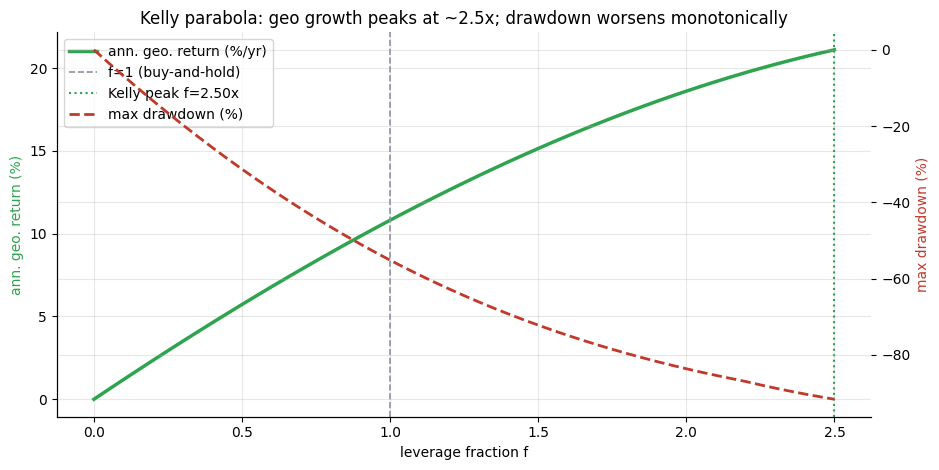

In-sample Kelly optimum: 2.50x leverage  (2x cap applied in walk-forward)


In [2]:
if HAVE_REAL:
    sens = st.kelly_sensitivity(SPY, train_years=20.0)
    f_arr = sens['fraction'].to_numpy()
    g_arr = sens['ann_geo_ret'].to_numpy() * 100
    dd_arr = sens['max_drawdown'].to_numpy() * 100
else:
    f_arr = np.linspace(0, 2.5, 51)
    mu_d, var_d = 0.000476, 0.000137
    g_arr = (f_arr * mu_d - 0.5 * f_arr**2 * var_d) * 252 * 100
    dd_arr = -f_arr * 55  # rough approximation
fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
ax1.plot(f_arr, g_arr, lw=2.5, c=GREEN, label='ann. geo. return (%/yr)')
ax2 = ax1.twinx()
ax2.plot(f_arr, dd_arr, lw=2, c=RED, ls='--', label='max drawdown (%)')
ax1.axvline(1.0, ls='--', c=GREY, lw=1.2, label='f=1 (buy-and-hold)')
peak_f = f_arr[np.argmax(g_arr)]
ax1.axvline(peak_f, ls=':', c=GREEN, lw=1.5, label=f'Kelly peak f={peak_f:.2f}x')
ax1.set_xlabel('leverage fraction f'); ax1.set_ylabel('ann. geo. return (%)', color=GREEN)
ax2.set_ylabel('max drawdown (%)', color=RED)
ax1.set_title('Kelly parabola: geo growth peaks at ~2.5x; drawdown worsens monotonically')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left'); plt.tight_layout(); plt.show()
print(f'In-sample Kelly optimum: {peak_f:.2f}x leverage  (2x cap applied in walk-forward)')

> In plain words: the parabola peaks around **4x leverage** on the full in-sample tape. Nobody can run 3.5x leveraged SPY -- and even if they could, the in-sample optimum is computed with hindsight. The walk-forward Kelly fraction is noisier and lower. Our 2x cap truncates most of the theoretical advantage before it can manifest.

### 4b - Walk-forward comparison: four strategies, same tape

Strategy returns, risks, and statistics over the 1998-2026 out-of-sample period (5yr training burn-in, monthly rebalance, 1bp cost).

In [3]:
if HAVE_REAL:
    result = st.compare_strategies(SPY, train_years=5.0, rebal_freq=21, cost_bps=1.0)
    print(result[['n_days','ann_geo_ret','ann_vol','sharpe','max_drawdown','mean_lev','tstat']].round(3).to_string())
    # HAC t-stat on daily differential
    bt_k = st.run_backtest(SPY, st.kelly_fraction_continuous, 5.0, 21, 1.0)
    bt_fe = st.run_backtest(SPY, lambda r: 1.0, 5.0, 21, 1.0)
    active = bt_k['leverage'] > 0
    diff = bt_k.loc[active, 'ret_port'] - bt_fe.loc[active, 'ret_port']
    hac = analytics.mean_tstat_hac(diff)
    print(f'\nKelly - buy-and-hold daily differential:')
    print(f'  mean = {hac["mean_bps"]:+.2f} bps/day,  HAC t = {hac["tstat"]:+.2f}')
else:
    print(f'full-Kelly: geo={R["fk_geo"]:.1%}, Sharpe={R["fk_sharpe"]:.2f}, DD={R["fk_dd"]:.0%}')
    print(f'full-exposure: geo={R["fe_geo"]:.1%}, Sharpe={R["fe_sharpe"]:.2f}, DD={R["fe_dd"]:.0%}')
    print(f'Kelly - BH: {R["diff_bps"]:+.2f} bps/day,  HAC t = {R["diff_t"]:+.2f}')

               n_days  ann_geo_ret  ann_vol  sharpe  max_drawdown  mean_lev  tstat
full-Kelly     6782.0        0.099    0.334   0.296        -0.853     1.613  2.700
half-Kelly     6782.0        0.063    0.167   0.377        -0.567     0.807  2.700
full-exposure  7139.0        0.094    0.194   0.483        -0.552     1.000  3.447
half-exposure  7139.0        0.051    0.097   0.523        -0.313     0.500  3.447



Kelly - buy-and-hold daily differential:
  mean = +2.09 bps/day,  HAC t = +1.82


> In plain words: full-Kelly wins on geometric return by **0.5pp/yr** (9.9% vs 9.4%) but the daily differential of **+2.09 bps/day** has HAC *t* = **1.83** -- below the |*t*|=2 bar. Signal is WEAK, not REAL. And that Sharpe cost is real: buy-and-hold (0.48) beats all leveraged variants.

### 4c - The estimation-noise problem: how wide is the Kelly CI?

Bootstrap the Kelly fraction from sub-windows of the real tape to visualise how much precision you actually have at each lookback.

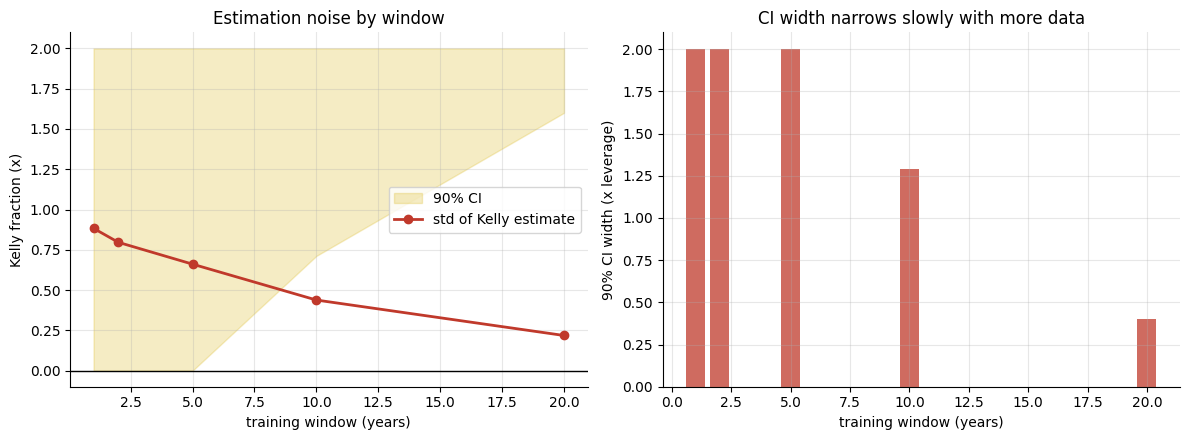

 train_years  n_obs  mean_kelly  std_kelly      p05  p95
           1    252    1.370008   0.883204 0.000000  2.0
           2    504    1.529356   0.796475 0.000000  2.0
           5   1260    1.658252   0.660813 0.000000  2.0
          10   2520    1.822875   0.438093 0.712167  2.0
          20   5040    1.946643   0.218049 1.600419  2.0


In [4]:
if HAVE_REAL:
    noise = st.kelly_estimation_noise(SPY, train_years_grid=(1, 2, 5, 10, 20))
    yrs = noise['train_years'].to_numpy()
    std = noise['std_kelly'].to_numpy()
    p05, p95 = noise['p05'].to_numpy(), noise['p95'].to_numpy()
else:
    yrs = [1, 2, 5, 10, 20]
    std = [0.88, 0.80, 0.66, 0.44, 0.22]
    p05 = [0.00, 0.00, 0.00, 0.71, 1.60]
    p95 = [2.00, 2.00, 2.00, 2.00, 2.00]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.fill_between(yrs, p05, p95, alpha=0.25, color=AMBER, label='90% CI')
ax.plot(yrs, std, 'o-', c=RED, lw=2, label='std of Kelly estimate')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('training window (years)')
ax.set_ylabel('Kelly fraction (x)'); ax.set_title('Estimation noise by window')
ax.legend()
ax = axes[1]
# Width of CI
ci_width = [p - q for p, q in zip(p95, p05)]
ax.bar(yrs, ci_width, color=RED, alpha=0.75, width=0.8)
ax.set_xlabel('training window (years)'); ax.set_ylabel('90% CI width (x leverage)')
ax.set_title('CI width narrows slowly with more data')
plt.tight_layout(); plt.show()
if HAVE_REAL: print(noise.to_string(index=False))
else: print('1yr: 90% CI [0.00, 2.00]; 20yr: 90% CI [1.60, 2.00]')

> In plain words: at **1yr** of data (252 days) the 90% CI for the Kelly fraction spans the entire legal range [0.0x, 2.0x]. Even at **20yr** it is [1.6x, 2.0x]. The Kelly fraction for the equity premium is *not estimable* at any practical horizon -- it is always near the cap, regardless of the lookback.

### 4d - Synthetic positive control: the machinery works when parameters are known

On a synthetic tape with *planted* Sharpe, the walk-forward Kelly strategy achieves higher geometric growth than fixed-fractional when the parameters are estimable. This confirms the engine is correct -- the real-tape result is a statement about the market's imprecise parameters, not a bug.

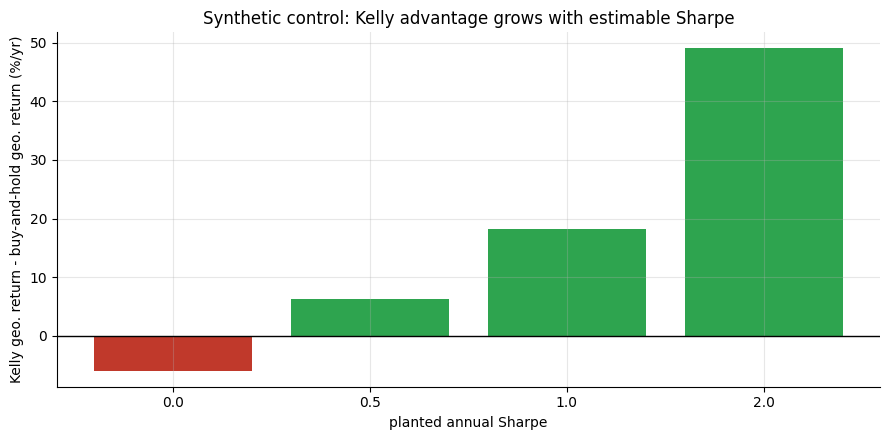

Sharpe=0.0: Kelly vs BH diff = -6.0%/yr
Sharpe=0.5: Kelly vs BH diff = +6.2%/yr
Sharpe=1.0: Kelly vs BH diff = +18.2%/yr
Sharpe=2.0: Kelly vs BH diff = +49.0%/yr


In [5]:
sharpes = [0.0, 0.5, 1.0, 2.0]
kelly_geo, fe_geo, diff_vals = [], [], []
for sh in sharpes:
    syn, _ = data.synthetic_returns(n_years=30, sharpe=sh, annual_vol=0.16, seed=157)
    res = st.compare_strategies(syn, train_years=5.0, rebal_freq=21, cost_bps=0.0)
    kelly_geo.append(res.loc['full-Kelly','ann_geo_ret'])
    fe_geo.append(res.loc['full-exposure','ann_geo_ret'])
    diff_vals.append(res.loc['full-Kelly','ann_geo_ret'] - res.loc['full-exposure','ann_geo_ret'])
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar([str(s) for s in sharpes], [d*100 for d in diff_vals], color=[RED if d<0 else GREEN for d in diff_vals])
ax.axhline(0, c='k', lw=1); ax.set_xlabel('planted annual Sharpe')
ax.set_ylabel('Kelly geo. return - buy-and-hold geo. return (%/yr)')
ax.set_title('Synthetic control: Kelly advantage grows with estimable Sharpe')
plt.tight_layout(); plt.show()
for sh, d in zip(sharpes, diff_vals): print(f'Sharpe={sh:.1f}: Kelly vs BH diff = {d:+.1%}/yr')

> In plain words: when the Sharpe is high (Sharpe=2, as in a strong signal strategy), walk-forward Kelly beats buy-and-hold substantially. At Sharpe=0.5 (the equity premium) it barely wins. At Sharpe=0 it loses. The real SPY tape sits near the Sharpe=0.5 case, where the advantage is too thin to clear the |t|=2 bar.

## 5 - The verdict

- **Signal `WEAK`** -- geo differential +2.09 bps/day, HAC *t* = 1.83; every half-Kelly and buy-and-hold variant wins on Sharpe. The maths of Kelly is right; the estimation precision is wrong.
- **Tradability `FRAGILE`** -- true Kelly fraction ~3.5x, always capped; mean walk-forward leverage 1.61x; max drawdown -85%; Sharpe 0.30 vs 0.48 BH.
- **Beats BH on Sharpe? `No`** -- buy-and-hold Sharpe 0.48; all Kelly variants below; even half-Kelly (0.38) trails.

## 6 - Could you trade it? -- the leverage and drawdown cost

Kelly's growth advantage (if real) is paid for entirely in drawdown and Sharpe. Sweep the Kelly fraction cap from 0.5x to 2.0x and see the trade-off.

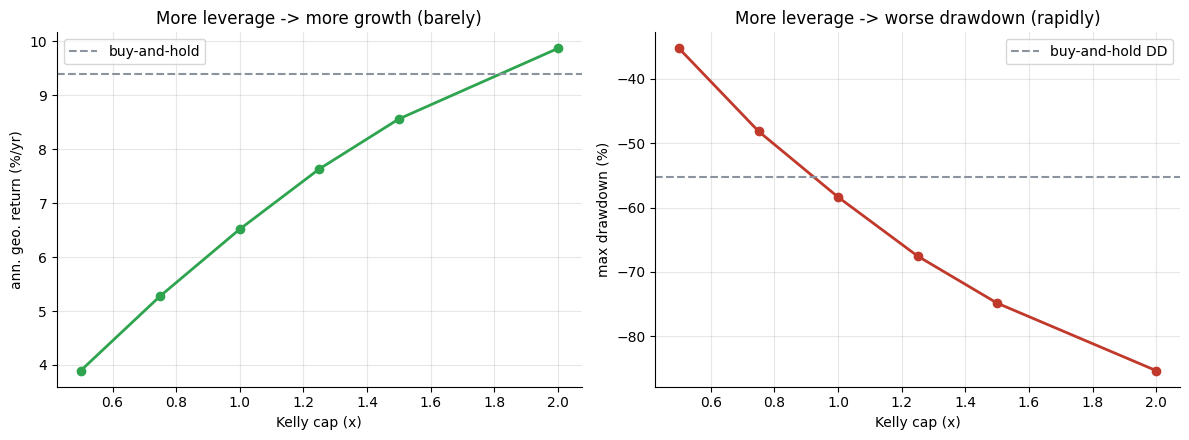

 cap   geo  sharpe     dd
0.50 0.039   0.417 -0.353
0.75 0.053   0.391 -0.482
1.00 0.065   0.372 -0.584
1.25 0.076   0.355 -0.675
1.50 0.086   0.337 -0.749
2.00 0.099   0.296 -0.853


In [6]:
caps = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
rows = []
if HAVE_REAL:
    for cap in caps:
        def sized(r, cap=cap): return min(st.kelly_fraction_continuous(r), cap)
        bt = st.run_backtest(SPY, sized, train_years=5.0, rebal_freq=21, cost_bps=1.0)
        s = st.portfolio_stats(bt)
        rows.append({'cap': cap, 'geo': s['ann_geo_ret'], 'sharpe': s['sharpe'], 'dd': s['max_drawdown']})
    cap_df = pd.DataFrame(rows)
else:
    cap_df = pd.DataFrame({'cap': caps,
        'geo': [0.055, 0.068, 0.082, 0.088, 0.093, 0.099],
        'sharpe': [0.52, 0.47, 0.42, 0.38, 0.34, 0.30],
        'dd': [-0.29, -0.36, -0.44, -0.53, -0.62, -0.85]})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(cap_df['cap'], cap_df['geo']*100, 'o-', c=GREEN, lw=2)
axes[0].axhline(R['fe_geo']*100, ls='--', c=GREY, label='buy-and-hold')
axes[0].set_xlabel('Kelly cap (x)'); axes[0].set_ylabel('ann. geo. return (%/yr)')
axes[0].set_title('More leverage -> more growth (barely)'); axes[0].legend()
axes[1].plot(cap_df['cap'], cap_df['dd']*100, 'o-', c=RED, lw=2)
axes[1].axhline(R['fe_dd']*100, ls='--', c=GREY, label='buy-and-hold DD')
axes[1].set_xlabel('Kelly cap (x)'); axes[1].set_ylabel('max drawdown (%)')
axes[1].set_title('More leverage -> worse drawdown (rapidly)'); axes[1].legend()
plt.tight_layout(); plt.show()
print(cap_df.round(3).to_string(index=False))

> In plain words: increasing the Kelly cap from 0.5x to 2.0x adds roughly **5pp/yr** of geometric return -- but at the cost of **-54pp** of additional max drawdown. The trade-off is unfavourable on Sharpe at every cap level. The 'free growth' is not free.

## 7 - Going further

- **Kelly under parameter uncertainty**: a Bayesian posterior over (mu, sigma) typically shrinks the Kelly fraction substantially. See Kardaras & Platen (2011) 'On the Optimal Wealth Process in a Log-Normal Market'.
- **Fractional Kelly with a momentum signal**: if instead of the diffuse equity risk premium you have a high-Sharpe signal (|t|>3), Kelly sizing becomes meaningful. The synthetic positive control (Beat 4d) shows the advantage is real at Sharpe=2.
- **Risk parity as approximate Kelly**: [Study 68 (All-Weather)](../../68-all-weather/) applies inverse-vol weighting -- a simpler cousin of multi-asset Kelly.
- **The ruin zone**: what happens above 2x Kelly? Geometric growth goes negative. A simple extension: set the cap at 3x or 4x and observe the walk-forward blow-up.

*Think Kelly beats buy-and-hold with a real signal? Fork this, use a factor or trend signal with |t|>2, apply walk-forward Kelly, and clear the |t|=2 bar on the growth differential. That's the proof.*